# EPFL Hackathon 2026 - Data Preprocesing

In [ ]:
import numpy as np
import pandas as pd

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz
from qiskit_aer.primitives import Estimator
from qiskit_aer import Aer
from qiskit import transpile
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

In [18]:
import numpy as np
import pandas as pd

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def generate_underwriting_dataset_consistent(
    N=24,
    n_brokers=10,
    n_garages=12,
    n_regions=6,
    n_devices=40,
    n_rings=3,
    ring_fraction=0.35,
    seed=0,
):
    """
    Fully consistent synthetic dataset:
      - Latent entity risks (broker/garage/device) are sampled first
      - Cases sample entities (rings reuse entities)
      - p_fraud is computed from features + latent entity risks (no leakage)
      - severity_L uses leakage_by_type * claim_amount
      - v_i = alpha * p_fraud * severity_L - review_cost
      - w_ij is built from (shared entity links) * (economic uplift + cost sharing + evidence rarity) - redundancy
    """
    rng = np.random.default_rng(seed)

    # -----------------------
    # 1) Global parameters
    # -----------------------
    claim_types = np.array(["auto", "home", "health"])
    type_probs  = np.array([0.55, 0.30, 0.15])

    leakage_by_type = {"auto": 0.30, "home": 0.40, "health": 0.20}

    alpha_effectiveness = 0.55   # P(review catches/mitigates | problematic)
    hourly_cost = 60.0           # cost per hour of reviewer

    # Link strength weights (how strong each shared-entity signal is)
    rho = {
        "broker": 0.25,
        "garage": 0.50,
        "device": 0.60,
        "region_type": 0.15
    }

    # Synergy scaling
    kappa_uplift = 0.18   # scales "network uplift" in money
    mu_costshare = 0.50   # fraction of min(review_cost) you save by bundling
    pi_evidence  = 30.0   # evidence/prosecution bonus scale (rarer shared entities => larger)
    delta_redund = 0.25   # redundancy penalty scale

    # -----------------------
    # 2) Latent entity risks (no circularity)
    # -----------------------
    # These are fixed unknown propensities in the world (what the insurer has learned historically)
    broker_risk_latent = rng.normal(0.0, 0.35, size=n_brokers)
    garage_risk_latent = rng.normal(0.0, 0.45, size=n_garages)
    device_risk_latent = rng.normal(0.0, 0.30, size=n_devices)

    # -----------------------
    # 3) Fraud rings (latent structure that reuses entities)
    # -----------------------
    in_ring = rng.random(N) < ring_fraction
    ring_id_latent = np.zeros(N, dtype=int)
    ring_id_latent[in_ring] = rng.integers(1, n_rings + 1, size=in_ring.sum())

    # Each ring uses small pools of entities (creates correlation)
    def make_pool(n_total, frac):
        m = max(1, int(np.round(n_total * frac)))
        return rng.choice(n_total, size=m, replace=False)

    ring_broker_pool = {r: make_pool(n_brokers, 0.25) for r in range(1, n_rings+1)}
    ring_garage_pool = {r: make_pool(n_garages, 0.25) for r in range(1, n_rings+1)}
    ring_device_pool = {r: make_pool(n_devices, 0.30) for r in range(1, n_rings+1)}

    def pick_entity(ring, pool_dict, n_total, reuse_prob=0.80):
        if ring == 0:
            return int(rng.integers(0, n_total))
        # ring tends to reuse within pool
        if rng.random() < reuse_prob:
            return int(rng.choice(pool_dict[ring]))
        return int(rng.integers(0, n_total))

    # -----------------------
    # 4) Generate case-level features
    # -----------------------
    rows = []
    for i in range(N):
        ctype = str(rng.choice(claim_types, p=type_probs))
        region = int(rng.integers(0, n_regions))
        ring = int(ring_id_latent[i])

        # Claim amount: type-dependent lognormal (right-skewed)
        if ctype == "auto":
            amount = float(rng.lognormal(mean=8.2, sigma=0.55))   # ~ few k to ~20k
        elif ctype == "home":
            amount = float(rng.lognormal(mean=8.7, sigma=0.60))   # larger typical
        else:
            amount = float(rng.lognormal(mean=7.9, sigma=0.50))   # smaller typical

        policy_age_days = int(rng.integers(5, 3650))
        prior_claims = int(rng.poisson(0.6))

        complexity = float(np.clip(rng.normal(1.0, 0.35), 0.3, 2.0))
        review_minutes = int(np.clip(20 + 35 * complexity + 8 * prior_claims, 15, 120))

        broker = pick_entity(ring, ring_broker_pool, n_brokers)
        garage = pick_entity(ring, ring_garage_pool, n_garages)
        device = pick_entity(ring, ring_device_pool, n_devices)

        # Node-level network exposure score (from latent entity risks)
        # (No circularity: uses broker_risk_latent etc.)
        entity_risk_score = (
            0.30 * broker_risk_latent[broker] +
            0.45 * garage_risk_latent[garage] +
            0.25 * device_risk_latent[device]
        )

        # -----------------------
        # 5) Pre-review fraud probability p_fraud
        # -----------------------
        # Uses only "metadata" + latent entity risks + mild ring effect (rings are harder)
        # This is what your model would estimate automatically.
        log_amount = np.log(max(amount, 1.0))
        young_policy = 1.0 if policy_age_days < 60 else 0.0

        type_shift = {"auto": 0.15, "home": 0.05, "health": -0.05}[ctype]

        score = (
            -3.2
            + type_shift
            + 0.50 * (log_amount - 8.2)
            + 0.65 * young_policy
            + 0.35 * prior_claims
            + 0.85 * entity_risk_score
            + 0.55 * (1.0 if ring != 0 else 0.0)
        )
        p_fraud = float(sigmoid(score))

        rows.append({
            "case_id": i,
            "claim_type": ctype,
            "region_id": region,
            "claim_amount": amount,
            "policy_age_days": policy_age_days,
            "prior_claims": prior_claims,
            "complexity": complexity,
            "review_minutes": review_minutes,
            "broker_id": broker,
            "garage_id": garage,
            "device_id": device,
            "entity_risk_score": float(entity_risk_score),
            "p_fraud": p_fraud,
            "ring_id_latent": ring,
        })

    df = pd.DataFrame(rows)

    # -----------------------
    # 6) Economics: severity_L, review_cost, v_i
    # -----------------------
    df["severity_L"] = df.apply(
        lambda r: leakage_by_type[r["claim_type"]] * r["claim_amount"],
        axis=1
    )
    df["review_cost"] = (df["review_minutes"] / 60.0) * hourly_cost

    # Expected value of reviewing:
    # v_i = alpha * p_fraud * severity_L - review_cost
    df["v_i"] = alpha_effectiveness * df["p_fraud"] * df["severity_L"] - df["review_cost"]

    # -----------------------
    # 7) Pairwise synergy matrix W (w_ij)
    # -----------------------
    # Define:
    #   s_ij = combined link strength from shared entities (in [0,1])
    #   evidence bonus higher if shared entity is rare in this batch
    #   redundancy penalty if cases are "too similar" and low incremental info
    N = len(df)
    W = np.zeros((N, N), dtype=float)

    # rarity counts within the batch (simple proxy)
    broker_counts = df["broker_id"].value_counts().to_dict()
    garage_counts = df["garage_id"].value_counts().to_dict()
    device_counts = df["device_id"].value_counts().to_dict()

    def rarity_bonus(count):
        # fewer occurrences => higher bonus, bounded
        return float(np.clip(1.0 / max(count, 1), 0.02, 0.50))

    v = df["v_i"].to_numpy()
    c = df["review_cost"].to_numpy()

    for i in range(N):
        for j in range(i+1, N):
            same_broker = df.loc[i, "broker_id"] == df.loc[j, "broker_id"]
            same_garage = df.loc[i, "garage_id"] == df.loc[j, "garage_id"]
            same_device = df.loc[i, "device_id"] == df.loc[j, "device_id"]
            same_region_type = (df.loc[i, "region_id"] == df.loc[j, "region_id"]) and (df.loc[i, "claim_type"] == df.loc[j, "claim_type"])

            # Combined link strength in [0,1] (no correlation coefficient!)
            s = 1.0
            if same_broker:      s *= (1.0 - rho["broker"])
            if same_garage:      s *= (1.0 - rho["garage"])
            if same_device:      s *= (1.0 - rho["device"])
            if same_region_type: s *= (1.0 - rho["region_type"])
            s = 1.0 - s

            if s == 0.0:
                continue

            # Evidence bonus: rare shared entities are stronger "proof" of a ring
            ev = 0.0
            if same_broker:
                ev += rarity_bonus(broker_counts[int(df.loc[i, "broker_id"])])
            if same_garage:
                ev += 1.5 * rarity_bonus(garage_counts[int(df.loc[i, "garage_id"])])
            if same_device:
                ev += 2.0 * rarity_bonus(device_counts[int(df.loc[i, "device_id"])])

            # Uplift term: only if both are economically promising
            vi = max(v[i], 0.0)
            vj = max(v[j], 0.0)
            uplift = kappa_uplift * np.sqrt(vi * vj)

            # Cost-sharing: handling linked cases together saves time/cost
            costshare = mu_costshare * min(c[i], c[j])

            # Redundancy penalty: if cases are extremely similar & low value, second adds little info
            # (you can tweak this rule)
            redundancy = 1.0 if (same_region_type and same_broker and abs(v[i]-v[j]) < 5.0 and max(vi, vj) < 20.0) else 0.0
            redund_pen = delta_redund * redundancy * (abs(v[i]) + abs(v[j])) * 0.10

            wij = s * (uplift + costshare + pi_evidence * ev) - redund_pen
            W[i, j] = wij
            W[j, i] = wij

    # Optional sparsification: keep only strongest edges for realism & easier optimization
    edges = [(i, j, W[i, j]) for i in range(N) for j in range(i+1, N) if W[i, j] != 0.0]
    edges = sorted(edges, key=lambda x: abs(x[2]), reverse=True)
    keep_m = max(1, 2 * N)  # keep ~2N edges
    keep = set((i, j) for i, j, _ in edges[:keep_m])
    for i, j, _ in edges:
        if (i, j) not in keep:
            W[i, j] = 0.0
            W[j, i] = 0.0

    return df, W

if __name__ == "__main__":
    df, W = generate_underwriting_dataset_consistent(N=24, seed=42)

    # >>> SAVE CSV HERE <<<
    df.to_csv("underwriting_dataset.csv", index=False)

    print(df.head(8)[[
        "case_id","claim_type","claim_amount","policy_age_days","prior_claims",
        "broker_id","garage_id","device_id","entity_risk_score","p_fraud",
        "severity_L","review_cost","v_i","ring_id_latent"
    ]])
    print("Non-zero edges in W:", int((np.abs(W) > 1e-12).sum() // 2))

   case_id claim_type  claim_amount  policy_age_days  prior_claims  broker_id  \
0        0       auto  18081.134056             1613             1          9   
1        1       auto   3369.652871             1604             2          3   
2        2       auto   4248.739891             2666             1          7   
3        3       auto  11738.840843             2027             2          3   
4        4       auto   1855.513637             3538             3          1   
5        5       auto   4027.007972             2727             1          0   
6        6       auto   8133.888356             2629             0          3   
7        7       auto   3826.943412              842             1          9   

   garage_id  device_id  entity_risk_score   p_fraud   severity_L  \
0         11         13          -0.142785  0.117113  5424.340217   
1          1         26           0.307181  0.106442  1010.895861   
2         11          9          -0.201575  0.057641  1274.6219

In [19]:
# 0) LOAD + SMALL BATCH
df = pd.read_csv("underwriting_dataset.csv")
df.columns = df.columns.str.strip()

v = df["v_i"].astype(float).to_numpy()
n = len(df)

# choose exactly K cases
K = min(5, n)
lam = 1.0

# penalty should dominate typical gains; start robustly
rho = 50.0 * max(1.0, np.max(np.abs(v)))  # scale with data magnitude

In [20]:
# 2) BUILD QUBO 
qp = QuadraticProgram("fraud_alert_prioritization")

for i in range(n):
    qp.binary_var(f"x_{i}")

linear = {}
quadratic = {}

def add_q(u, vname, c):
    key = tuple(sorted((u, vname)))
    quadratic[key] = quadratic.get(key, 0.0) + float(c)

# (A) -sum v_i x_i
for i in range(n):
    linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) - float(v[i])

# (B) -lam * sum_{i<j} W_ij x_i x_j
for i in range(n):
    for j in range(i + 1, n):
        if W[i, j] != 0.0:
            add_q(f"x_{i}", f"x_{j}", -lam * float(W[i, j]))

# (C) rho*(sum x - K)^2
# Expand: rho*(sum x)^2 - 2*rho*K*(sum x) + const
# and (sum x)^2 = sum x_i + 2*sum_{i<j} x_i x_j
for i in range(n):
    linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) + rho
    linear[f"x_{i}"] = linear.get(f"x_{i}", 0.0) - 2.0 * rho * K

for i in range(n):
    for j in range(i + 1, n):
        add_q(f"x_{i}", f"x_{j}", 2.0 * rho)

qp.minimize(linear=linear, quadratic=quadratic)
qubo = QuadraticProgramToQubo().convert(qp)

In [21]:
# 2) QAOA (ROBUST: Estimator + COBYLA)
H, offset = qubo.to_ising()

reps = 2
ansatz = QAOAAnsatz(cost_operator=H, reps=reps)

estimator = Estimator()

def energy(theta):
    job = estimator.run([ansatz], [H], [theta])
    return float(job.result().values[0])

theta0 = np.random.default_rng(0).uniform(0, 2*np.pi, size=ansatz.num_parameters)
opt = minimize(energy, theta0, method="COBYLA", options={"maxiter": 200})
theta_star = opt.x

# sample optimized circuit
qc = ansatz.assign_parameters(theta_star)
qc.measure_all()

backend = Aer.get_backend("aer_simulator")
tqc = transpile(qc, backend)
counts = backend.run(tqc, shots=10000).result().get_counts()

In [22]:
# 3) DECODE + pick BEST FEASIBLE 
var_names = [var.name for var in qubo.variables]  # should be x_0..x_{n-1}

def decode(bitstring):
    bits = np.array([int(b) for b in bitstring[::-1]], dtype=int)  # reverse to qubit order
    if len(bits) != len(var_names):
        raise ValueError(f"len(bits)={len(bits)} != num_vars={len(var_names)}")
    assign = dict(zip(var_names, bits))
    x = np.array([assign[f"x_{i}"] for i in range(n)], dtype=int)
    return x

def score_business(x):
    # value + synergy, for reporting
    val = float(np.sum(v * x))
    syn = 0.0
    for i in range(n):
        for j in range(i + 1, n):
            syn += W[i, j] * x[i] * x[j]
    return val + lam * float(syn), val, float(syn)

best_feasible = None
best_feasible_score = -1e18

# search feasible bitstrings among measured samples
for bitstr, ct in counts.items():
    x = decode(bitstr)
    if int(x.sum()) == K:
        total, val, syn = score_business(x)
        if total > best_feasible_score:
            best_feasible_score = total
            best_feasible = (bitstr, x, val, syn)

# fallback: if no feasible found, take most frequent
if best_feasible is None:
    best_bitstr = max(counts, key=counts.get)
    x = decode(best_bitstr)
    total, val, syn = score_business(x)
else:
    best_bitstr, x, val, syn = best_feasible
    total = val + lam * syn

selected_idx = np.where(x == 1)[0]

In [23]:
# 4) REPORT
print("Used n =", n, "K =", K, "rho =", rho, "reps =", reps)
print("Best bitstring:", best_bitstr)
print("Selected count:", int(x.sum()), "(target K =", K, ")")
print("Selected indices (within df_small):", selected_idx.tolist())
print("Sum individual value:", val)
print("Network synergy term:", lam * syn)
print("Total (value + synergy):", total)

# show selected rows 
display(df.loc[selected_idx].reset_index(drop=True))

Used n = 24 K = 5 rho = 26411.02345623568 reps = 2
Best bitstring: 000000000001001000001101
Selected count: 5 (target K = 5 )
Selected indices (within df_small): [0, 2, 3, 9, 12]
Sum individual value: 815.5940104574761
Network synergy term: 33.170638665364244
Total (value + synergy): 848.7646491228403


,case_id,claim_type,region_id,claim_amount,policy_age_days,prior_claims,complexity,review_minutes,broker_id,garage_id,device_id,entity_risk_score,p_fraud,ring_id_latent,severity_L,review_cost,v_i
0,0,auto,0,18081.134056,1613,1,1.093699,66,9,11,13,-0.142785,0.117113,0,5424.340217,66.0,283.394320
1,2,auto,4,4248.739891,2666,1,0.825247,56,7,11,9,-0.201575,0.057641,0,1274.621967,56.0,-15.591140
2,3,auto,0,11738.840843,2027,2,1.326051,82,3,8,7,0.308957,0.278471,3,3521.652253,82.0,457.373428
3,9,auto,3,7597.457715,2421,0,0.756420,46,6,3,5,0.269098,0.129715,2,2279.237314,46.0,116.608013
4,12,auto,2,1793.487954,3630,1,0.589952,48,6,9,32,-0.031965,0.073699,2,538.046386,48.0,-26.190610


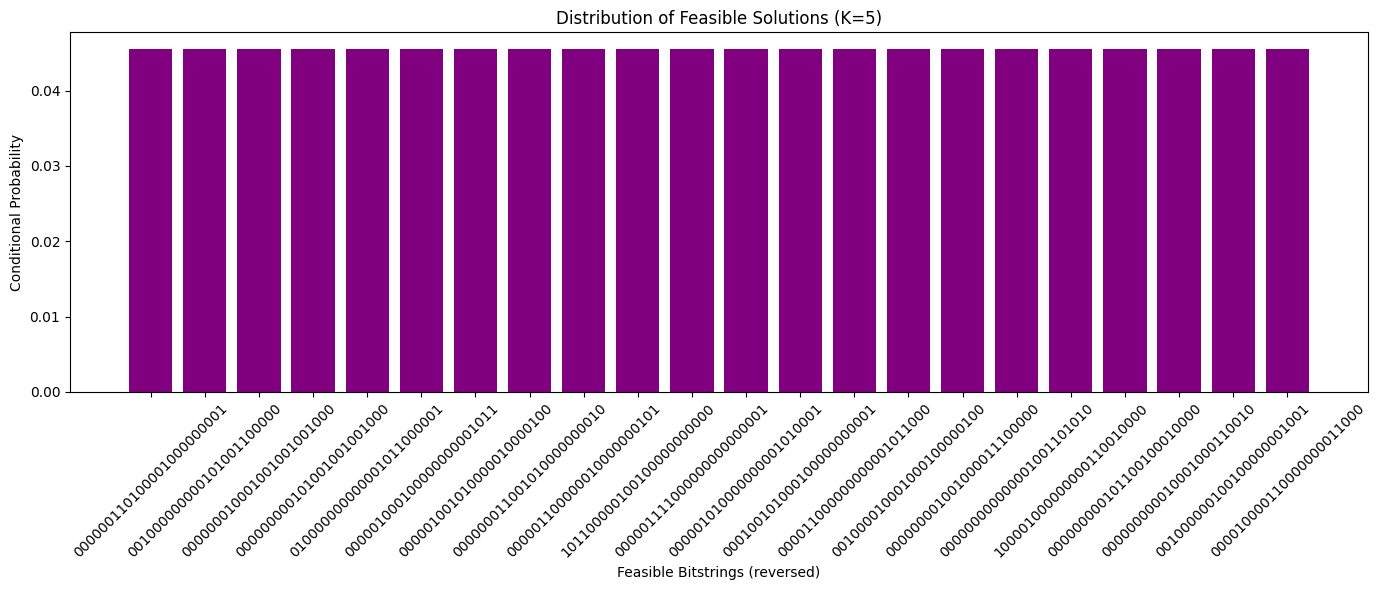

In [24]:
# === Histogram of ONLY feasible solutions (sum(x) == K) ===
import matplotlib.pyplot as plt
import numpy as np

# Total shots
total_shots = sum(counts.values())

# Filter feasible bitstrings
feasible_counts = {}

for bitstr, ct in counts.items():
    x = decode(bitstr)
    if int(x.sum()) == K:
        feasible_counts[bitstr] = ct

# Check if we found feasible solutions
if len(feasible_counts) == 0:
    print("No feasible solutions found in samples.")
else:
    # Normalize probabilities among feasible ones
    feasible_total = sum(feasible_counts.values())
    probs = {b: c / feasible_total for b, c in feasible_counts.items()}
    
    # Sort by probability descending
    sorted_items = sorted(probs.items(), key=lambda x: -x[1])
    
    TOP_M = 25
    sorted_items = sorted_items[:TOP_M]
    
    labels = [b[::-1] for b, _ in sorted_items]
    values = [p for _, p in sorted_items]
    
    plt.figure(figsize=(14, 6))
    plt.bar(labels, values, color="purple")
    plt.xticks(rotation=45)
    plt.ylabel("Conditional Probability")
    plt.xlabel("Feasible Bitstrings (reversed)")
    plt.title(f"Distribution of Feasible Solutions (K={K})")
    plt.tight_layout()
    plt.show()

In [26]:
# ==========================================================
# OPTION B (FIXED): Constrained QAOA with XY-mixer (exact-K)
# Key fix: build a NEW cost Hamiltonian WITHOUT the rho penalty
# ==========================================================

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RXXGate, RYYGate, RZZGate
from qiskit_aer import Aer
from qiskit_aer.primitives import Estimator as AerEstimator
from scipy.optimize import minimize

# -------------------------------
# 1) Build a NEW QUBO for objective only (NO exactly-K penalty here)
#    We keep:  maximize sum v_i x_i + lam * sum W_ij x_i x_j
#    => minimize: -sum v_i x_i - lam * sum W_ij x_i x_j
# -------------------------------
qp_obj = QuadraticProgram("fraud_obj_only")
for i in range(n):
    qp_obj.binary_var(f"x_{i}")

linear_obj = {f"x_{i}": -float(v[i]) for i in range(n)}  # -v_i
quadratic_obj = {}

def add_q_obj(u, vname, c):
    key = tuple(sorted((u, vname)))
    quadratic_obj[key] = quadratic_obj.get(key, 0.0) + float(c)

for i in range(n):
    for j in range(i + 1, n):
        if W[i, j] != 0.0:
            add_q_obj(f"x_{i}", f"x_{j}", -lam * float(W[i, j]))

qp_obj.minimize(linear=linear_obj, quadratic=quadratic_obj)
qubo_obj = QuadraticProgramToQubo().convert(qp_obj)

H_obj, offset_obj = qubo_obj.to_ising()

# -------------------------------
# 2) Constrained-QAOA circuit: initial weight-K + XY mixer
# -------------------------------
def initial_state_weight_k(n, K):
    qc0 = QuantumCircuit(n)
    # Put exactly K ones. NOTE: which indices are "1" is arbitrary; mixer should move them.
    for q in range(K):
        qc0.x(q)
    return qc0

def apply_cost_layer(qc, gamma, H):
    # For Ising terms: sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j
    for pauli, coeff in H.to_list():
        coeff = float(np.real(coeff))
        z_idx = [k for k, p in enumerate(pauli[::-1]) if p == "Z"]
        if len(z_idx) == 1:
            qc.rz(2 * gamma * coeff, z_idx[0])
        elif len(z_idx) == 2:
            i, j = z_idx
            qc.append(RZZGate(2 * gamma * coeff), [i, j])
        # constants / identity terms can be ignored

def apply_xy_mixer_layer(qc, beta, edges):
    # exp(-i beta sum (XX+YY)) = product over edges of RXX(2beta) then RYY(2beta)
    for i, j in edges:
        qc.append(RXXGate(2 * beta), [i, j])
        qc.append(RYYGate(2 * beta), [i, j])

# Mixer connectivity:
# IMPORTANT: must be connected so any weight-K configuration is reachable.
# Ring is connected and cheap; complete graph is stronger but deeper.
xy_edges = [(i, (i + 1) % n) for i in range(n)]  # ring graph

p_xy = 2
gammas = ParameterVector("g", p_xy)
betas  = ParameterVector("b", p_xy)

qc_xy = QuantumCircuit(n)
qc_xy.compose(initial_state_weight_k(n, K), inplace=True)

for layer in range(p_xy):
    apply_cost_layer(qc_xy, gammas[layer], H_obj)
    apply_xy_mixer_layer(qc_xy, betas[layer], xy_edges)

# -------------------------------
# 3) Optimize <H_obj> with AerEstimator (multi-start to avoid beta~0 trap)
# -------------------------------
est_xy = AerEstimator()
backend = Aer.get_backend("aer_simulator")

def energy_xy(theta):
    return float(est_xy.run([qc_xy], [H_obj], [theta]).result().values[0])

best_theta = None
best_E = +1e99

rng = np.random.default_rng(123)
n_params = 2 * p_xy

for r in range(5):  # 5 random restarts
    theta0 = rng.uniform(0, 2*np.pi, size=n_params)
    opt = minimize(energy_xy, theta0, method="COBYLA", options={"maxiter": 250})
    E = float(opt.fun)
    if E < best_E:
        best_E = E
        best_theta = opt.x

# quick debug: check if betas are ~0 (then mixer is "off")
print("\n[XY debug] gammas =", np.round(best_theta[:p_xy], 4))
print("[XY debug] betas  =", np.round(best_theta[p_xy:], 4))

# -------------------------------
# 4) Sample and decode (should ALWAYS satisfy sum(x)=K)
# -------------------------------
qc_xy_final = qc_xy.assign_parameters(best_theta)
qc_xy_final.measure_all()
tqc = transpile(qc_xy_final, backend)
counts_xy = backend.run(tqc, shots=5000).result().get_counts()

best_bit = max(counts_xy, key=counts_xy.get)
bits = np.array([int(b) for b in best_bit[::-1]], dtype=int)
x_xy = bits[:n]
sel_xy = np.where(x_xy == 1)[0]

print("\n=== Constrained XY-mixer run (FIXED) ===")
print("Best bitstring:", best_bit)
print("Selected count:", int(x_xy.sum()), "(must equal K =", K, ")")
print("Selected indices:", sel_xy.tolist())

# Optional: business score for comparison
val_xy = float(np.sum(v * x_xy))
syn_xy = 0.0
for i in range(n):
    for j in range(i + 1, n):
        syn_xy += W[i, j] * x_xy[i] * x_xy[j]
syn_xy = float(syn_xy)

print("Sum individual value:", val_xy)
print("Network synergy term:", lam * syn_xy)
print("Total (value + synergy):", val_xy + lam * syn_xy)


[XY debug] gammas = [3.1413 4.7269]
[XY debug] betas  = [5.5742 3.6109]

=== Constrained XY-mixer run (FIXED) ===
Best bitstring: 000000000000000000011111
Selected count: 5 (must equal K = 5 )
Selected indices: [0, 1, 2, 3, 4]
Sum individual value: 688.79156918341
Network synergy term: 52.170638665364244
Total (value + synergy): 740.9622078487743
